In [1]:
# ==========================================
# 1. LIBRERÍAS
# ==========================================
import pandas as pd
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report




In [3]:
# ==========================================
# 2. CARGAR DATOS
# ==========================================
# Usaremos 4 categorías para hacerlo más rápido
categories = ['sci.space', 'rec.autos', 'talk.politics.mideast', 'comp.graphics']

data = fetch_20newsgroups(subset='all', categories=categories, remove=('headers', 'footers', 'quotes'))

X = data.data
y = data.target

print("Ejemplo de texto:\n", X[0][:301], "...\n")
print("Clases:", data.target_names)



Ejemplo de texto:
 I believe many people will be happy to have this information.   So, 
please post it to the comp.graphics. ...

Clases: ['comp.graphics', 'rec.autos', 'sci.space', 'talk.politics.mideast']


In [13]:
import random

print("Ejemplo de 5 textos aleatorios:")
for _ in range(5):
    print("-", random.choice(X)[:301], "...\n")

Ejemplo de 5 textos aleatorios:
- 


A developable surface is s.t. you can lay it (or roll it) flat on the
plane (it may require you to give it a "cut" though...)

E.g., a cylinder, a cone, a plane (of course!) or any surface or patch
having vanishing Gaussian (intrinsic) curvature (i.e., with singular
Hessian, the matrix of 2nd deri ...

- 
Archer> How about "Interactive Sex with Madonna"?

or "Sexium" for short.

/Lars ...

- Monthly posting regarding the Buick Grand National / Regal T-Type mailing list.

This list is for owners and other parties interested in the 82-87 Buick Grand
Nationals, Regal T-Types, GNXs, and other turbocharged Regals. Discussions 
include technical information and parts sources. Particular emphas ...

- 
This activity is regularly reported in Ron's interesting posts. Could
someone explain what the Command Loss Timer is?

Thanks, Alan ...

- 
Not exactly the same, but reminiscent of the assassination of Count
Bernadotte, who was _the_ UN negotiator during the

In [14]:
# ==========================================
# 3. DIVISIÓN TRAIN/TEST
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# ==========================================
# 4. PREPROCESAMIENTO DE TEXTO
# ==========================================
# Convertir texto en matriz de conteos de palabras
count_vect = CountVectorizer(stop_words='english')
X_train_counts = count_vect.fit_transform(X_train)
X_test_counts = count_vect.transform(X_test)

# Aplicar TF-IDF (opcional, mejora resultados)
tfidf = TfidfTransformer()
X_train_tfidf = tfidf.fit_transform(X_train_counts)
X_test_tfidf = tfidf.transform(X_test_counts)



<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 198237 stored elements and shape (2723, 32167)>

In [16]:
# Ejemplo rápido de CountVectorizer con algunos datos de muestra
from sklearn.feature_extraction.text import CountVectorizer

# Tomamos los primeros 5 textos para el ejemplo
sample_data = X[:5]

# Creamos una instancia de CountVectorizer
vectorizer_example = CountVectorizer()

# Ajustamos y transformamos los datos de muestra
X_sample_counts = vectorizer_example.fit_transform(sample_data)

# Mostramos el vocabulario aprendido
print("Vocabulario:", vectorizer_example.get_feature_names_out()[:20], "...") # Mostramos solo las primeras 20 palabras

# Mostramos la matriz de conteo para los datos de muestra
print("\nMatriz de conteo (primeras 5 filas, 20 columnas):")
print(X_sample_counts[:5, :20].todense()) # .todense() para ver la matriz completa (para ejemplos pequeños)

Vocabulario: ['above' 'act' 'advance' 'afterwhich' 'agree' 'all' 'also' 'am' 'amal'
 'and' 'another' 'are' 'argument' 'arms' 'as' 'assume' 'at' 'attempts'
 'be' 'bearing'] ...

Matriz de conteo (primeras 5 filas, 20 columnas):
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [1 1 0 1 1 0 2 1 1 4 1 2 1 1 3 1 0 1 5 1]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 3 0 0 0 0 0 0 2 0 0 0]]


**Explicación:**

`CountVectorizer` convierte una colección de documentos de texto en una matriz de conteos de tokens (palabras).

1.  **`vectorizer_example = CountVectorizer()`**: Creamos un objeto `CountVectorizer`.
2.  **`X_sample_counts = vectorizer_example.fit_transform(sample_data)`**: Este paso hace dos cosas:
    *   **`fit`**: Aprende el vocabulario de las palabras únicas en `sample_data`.
    *   **`transform`**: Convierte los documentos en una matriz donde cada fila es un documento y cada columna es una palabra del vocabulario. El valor en cada celda es el número de veces que esa palabra aparece en ese documento.
3.  **`vectorizer_example.get_feature_names_out()`**: Te da la lista de palabras en el vocabulario aprendido.
4.  **`X_sample_counts`**: Es la matriz que resulta de la transformación.

En resumen, transforma tus textos en números para que el modelo de Machine Learning pueda trabajar con ellos.

In [17]:
# ==========================================
# 5. MODELO MULTINOMIAL NAIVE BAYES
# ==========================================
model = MultinomialNB(alpha=1.0)  # alpha = parámetro de suavizado de Laplace
model.fit(X_train_tfidf, y_train)
y_pred = model.predict(X_test_tfidf)

# ==========================================
# 6. EVALUACIÓN
# ==========================================
print("Exactitud:", round(accuracy_score(y_test, y_pred), 3))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred, target_names=data.target_names))



Exactitud: 0.887

Matriz de confusión:
 [[269   6  17   6]
 [  7 255  25  23]
 [ 20   4 265   9]
 [  2   5   8 246]]

Reporte de clasificación:
                        precision    recall  f1-score   support

        comp.graphics       0.90      0.90      0.90       298
            rec.autos       0.94      0.82      0.88       310
            sci.space       0.84      0.89      0.86       298
talk.politics.mideast       0.87      0.94      0.90       261

             accuracy                           0.89      1167
            macro avg       0.89      0.89      0.89      1167
         weighted avg       0.89      0.89      0.89      1167



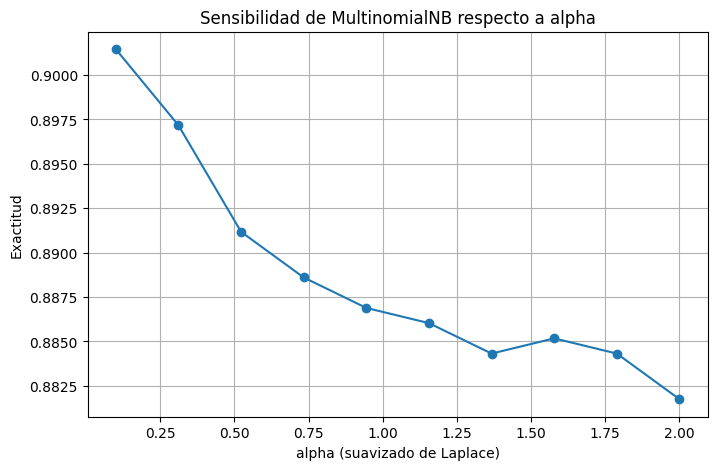

In [18]:
# ==========================================
# 7. ANÁLISIS DE SENSIBILIDAD (alpha)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt

alphas = np.linspace(0.1, 2, 10)
accuracies = []

for a in alphas:
    model = MultinomialNB(alpha=a)
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

plt.figure(figsize=(8,5))
plt.plot(alphas, accuracies, marker='o')
plt.title("Sensibilidad de MultinomialNB respecto a alpha")
plt.xlabel("alpha (suavizado de Laplace)")
plt.ylabel("Exactitud")
plt.grid(True)
plt.show()